# ArXiv Metadata — Exploratory Data Analysis

Profiles the [Kaggle arXiv snapshot](https://www.kaggle.com/datasets/Cornell-University/arxiv)
before any crawling happens, so the crawl can be scoped deliberately rather than guessed at.

<b>How this notebook handles a 4.5 GB file</b>

The snapshot is JSON Lines, one record per line, and far too large to load into a DataFrame
(`pd.read_json` on it will exhaust memory). Section 0 makes a **single streaming pass**,
accumulating counters rather than rows, and caches the aggregates to `data/eda/*.parquet`.
Every later cell reads those small cached tables, so re-running is instant and the expensive
pass happens exactly once.

To force a re-read after downloading a fresh snapshot, set `REBUILD = True` below.

# Setup

In [1]:
import json
import os
import sys
import itertools

from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
def find_repo_root(marker: str = "config.yaml") -> Path:
    p = Path.cwd().resolve()
    for parent in (p, *p.parents):
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not locate repo root (no {marker} found above {p})")

REPO = find_repo_root()
sys.path.insert(0, str(REPO))

from src.config import Config
from src.utils.prepare_data import iter_records, parse_record

In [3]:
cfg = Config.load()

CONFIG = {
    'METADATA': Path(cfg.paths.metadata_file),
    'EDA_DIR': cfg.paths.eda_dir,
    'REBUILD': False, # set True to redo the streaming pass after a fresh download
}

CONFIG['EDA_DIR'].mkdir(parents=True, exist_ok=True)

if not CONFIG['METADATA'].exists():
    print(CONFIG['METADATA'])
    raise SystemExit(
            f'Snapshot not found at {CONFIG['METADATA']}.\n'
            'Download it with:\n'
            '  kaggle datasets download -d Cornell-University/arxiv -p data/metadata --unzip'
        )

print(f'snapshot: {CONFIG['METADATA']}  ({CONFIG['METADATA'].stat().st_size / 1e9:.2f} GB)')

snapshot: /Users/reubenzs/Developer/arxiv-crawler/data/raw/arxiv-metadata-oai-snapshot.json  (5.50 GB)


In [4]:
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

# Dataset Setup

In [5]:
# Cache setup
CONFIG['EDA_TOPICS'] = ['primary_category', 'all_categories', 'monthly', 'archive_month', 'archive_year', 'n_categories', 'co_occurrence', 'n_versions', 'title_len', 'missingness', 'summary']

CONFIG['CACHE'] = {name: CONFIG['EDA_DIR'] / f"{name}.csv" for name in CONFIG['EDA_TOPICS']}

In [6]:
# Helper function
def bucket(value, width):
    """Round down the bucket value"""
    return (value // width) * width

In [7]:
def stream_aggregate(path):
    count = {k: Counter() for k in CONFIG['CACHE']}

    total, missing, first_month, last_month = 0, Counter(), '9999-99', '0000-00'

    for record in iter_records(path=path):
        parsed = parse_record(record)
        total += 1

        categories = parsed['categories']

        if parsed['primary_category']:
            count['primary_category'][parsed['primary_category']] += 1

        for category in set(categories):
            count['all_categories'][category] += 1

        count['n_categories'][len(categories)] += 1

        # Handle unordered pairs
        for a, b in itertools.combinations(sorted(set(categories)), 2):
            count['co_occurrence'][(a, b)] += 1

        released = parsed['date_released']
        if released:
            month, year = released[:7], released[:4]

            count['monthly'][month] += 1

            first_month, last_month = min(first_month, month), max(last_month, month)

            for archive in {cat.split(".")[0] for cat in categories}:
                count['archive_month'][(archive, month)] += 1
                count['archive_year'][(archive, year)] += 1

        count['n_versions'][parsed['n_versions']] += 1
        count['title_len'][bucket(len(parsed['title'] or ''), 10)] += 1

        for field in ['doi', 'date_released']:
            if not parsed.get(field):
                missing[field] += 1

    count['missingness'] = missing
    count['summary'] = Counter({'total_records': total})

    return count, total, first_month, last_month

In [8]:
def to_frame(counter, keys, value='papers'):
    """Turn counter to dataframe"""
    if not counter:
        return pd.DataFrame(columns=list(keys) + [value])

    rows = [(k if isinstance(k, tuple) else (k,)) + (v,) for k, v in counter.items()]
    return pd.DataFrame(rows, columns=list(keys) + [value])

In [9]:
CONFIG['SCHEMA'] = {
    'primary_category': ['category'], 'all_categories': ['category'], 'monthly': ['month'], 'archive_year': ['archive', 'year'], 'archive_month': ['archive', 'month'],
    'n_categories': ['n_categories'], 'co_occurrence': ['category_a', "category_b"], 'n_versions': ['n_versions'], 'title_len': ['chars'],
    'missingness': ['field'], 'summary': ['metric']
}

In [10]:
CONFIG['SOURCE_BYTES'] = CONFIG['METADATA'].stat().st_size
CONFIG['STALE'] = False

if CONFIG['CACHE']['summary'].exists():
    prev = pd.read_csv(CONFIG['CACHE']['summary'])
    prev = dict(zip(prev['metric'], prev['papers'].astype(str)))
    CONFIG['STALE'] = prev.get('source_bytes') != str(CONFIG['SOURCE_BYTES'])
    if CONFIG['STALE']:
        print('cached aggregates were built from a different snapshot -- rebuilding')

if CONFIG['REBUILD'] or CONFIG['STALE'] or not all(p.exists() for p in CONFIG['CACHE'].values()):
    print('streaming pass over the snapshot (this is the slow part, once)...')
    counters, total, first_month, last_month = stream_aggregate(CONFIG['METADATA'])
    counters['summary']['first_month'] = first_month
    counters['summary']['last_month'] = last_month
    counters['summary']['source_bytes'] = CONFIG['SOURCE_BYTES']

    for name, keys in CONFIG['SCHEMA'].items():
        frame = to_frame(counters[name], keys)
        frame.to_csv(CONFIG['CACHE'][name], index=False)

    print(f'cached {len(CONFIG['SCHEMA'])} aggregate tables to {CONFIG['EDA_DIR']}')

else:
    print(f'using cached aggregates in {CONFIG['EDA_DIR']} (set REBUILD = True to redo)')

streaming pass over the snapshot (this is the slow part, once)...


reading snapshot: 100%|██████████| 5.12G/5.12G [01:08<00:00, 80.5MB/s]


cached 11 aggregate tables to /Users/reubenzs/Developer/arxiv-crawler/data/processed/eda


In [11]:
agg = {name: pd.read_csv(path) for name, path in CONFIG['CACHE'].items()}
summary = dict(zip(agg['summary']['metric'], agg['summary']['papers']))
TOTAL = int(summary['total_records'])
print(f'{TOTAL:,} records')

3,148,882 records


# EDA

## Overview

In [12]:
span = agg['monthly'].sort_values('month')
print(f"records          {TOTAL:,}")
print(f"date span        {span['month'].min()} to {span['month'].max()}")
print(f"distinct months  {len(span):,}")
print(f"categories       {agg['all_categories']['category'].nunique():,}")
print(f"snapshot size    {CONFIG['METADATA'].stat().st_size / 1e9:.2f} GB")

miss = agg['missingness'].copy()
miss['missing_%'] = (miss['papers'] / TOTAL * 100).round(1)
miss = miss.sort_values('missing_%', ascending=False)
print('\nField coverage — how often each field is absent:')
display(miss.set_index('field'))

records          3,148,882
date span        1986-04 to 2026-08
distinct months  444
categories       176
snapshot size    5.50 GB

Field coverage — how often each field is absent:


,papers,missing_%
field,,
doi,1819142,57.8


## Papers per category

In [13]:
primary = agg['primary_category'].sort_values('papers', ascending=False).reset_index(drop=True)
allcats = agg['all_categories'].sort_values('papers', ascending=False).reset_index(drop=True)

assert primary['papers'].sum() <= TOTAL, 'primary counts must not exceed the record count'
print(f"primary categories    {len(primary):,} distinct, {primary['papers'].sum():,} papers")
print(f"all categories        {len(allcats):,} distinct, {allcats['papers'].sum():,} assignments")
print(f"cross-listing inflation  {allcats['papers'].sum() / max(TOTAL, 1):.2f}x")

primary categories    171 distinct, 3,148,882 papers
all categories        176 distinct, 5,465,898 assignments
cross-listing inflation  1.74x


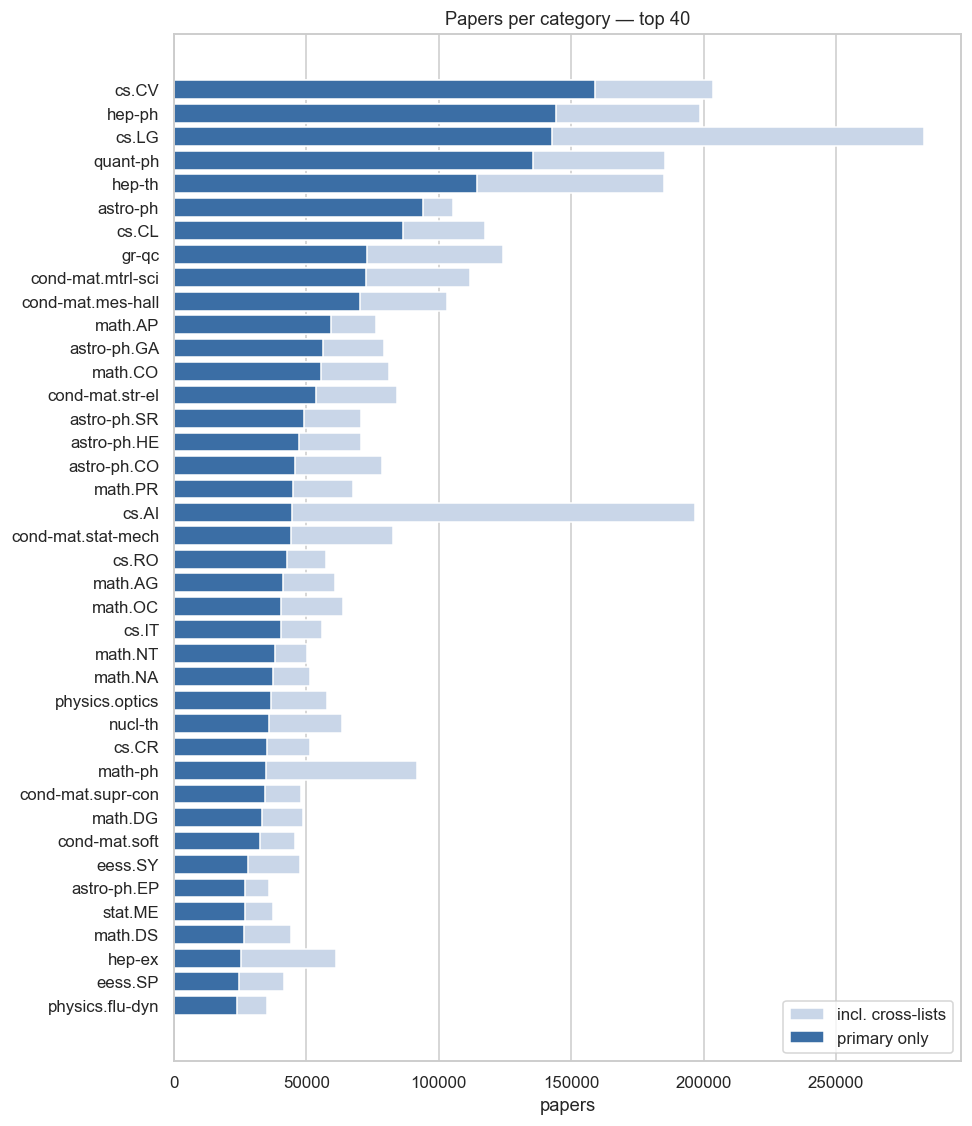

In [14]:
CONFIG['TOP_N'] = 40
merged = (primary.rename(columns={'papers': 'primary'})
          .merge(allcats.rename(columns={'papers': 'all'}), on='category', how='outer')
          .fillna(0))
merged[['primary', 'all']] = merged[['primary', 'all']].astype(int)
merged = merged.sort_values('primary', ascending=False)
top = merged.head(CONFIG['TOP_N']).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, CONFIG['TOP_N'] * 0.26))
y = range(len(top))
ax.barh(y, top['all'], color='#c9d6e8', label='incl. cross-lists')
ax.barh(y, top['primary'], color='#3b6ea5', label='primary only')
ax.set_yticks(list(y)); ax.set_yticklabels(top['category'])
ax.set_xlabel('papers'); ax.set_title(f'Papers per category — top {CONFIG['TOP_N']}')
ax.legend(loc='lower right'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

In [15]:
print('Full table — every category, primary count and cross-listed count:')
table = merged.copy()
table['share_%'] = (table['primary'] / TOTAL * 100).round(2)
# float NaN, not pd.NA: some categories are cross-listed to but never primary,
# and NA has no __round__.
table['cross_list_ratio'] = (table['all'] / table['primary'].replace(0, float('nan'))).round(2)
display(table.reset_index(drop=True))

Full table — every category, primary count and cross-listed count:


,category,primary,all,share_%,cross_list_ratio
0,cs.CV,158818,203562,5.04,1.28
1,hep-ph,144412,198717,4.59,1.38
2,cs.LG,142874,283148,4.54,1.98
3,quant-ph,135563,185325,4.31,1.37
4,hep-th,114380,185128,3.63,1.62
...,...,...,...,...,...
171,q-bio,0,1356,0.00,NaN
172,math.MP,0,91911,0.00,NaN
173,math.IT,0,55770,0.00,NaN
174,cs.NA,0,51227,0.00,NaN


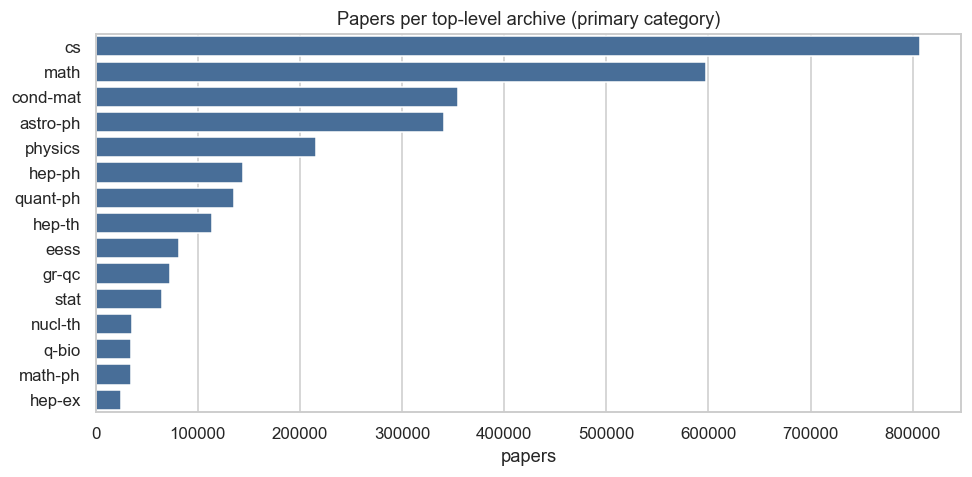

,archive,papers,share_%
0,cs,807347,25.6
1,math,597672,19.0
2,cond-mat,354424,11.3
3,astro-ph,341511,10.8
4,physics,215980,6.9
5,hep-ph,144412,4.6
6,quant-ph,135563,4.3
7,hep-th,114380,3.6
8,eess,81408,2.6
9,gr-qc,73012,2.3


In [16]:
# Top-level archive rollup (cs, math, physics, ...): the coarse shape of the corpus.
archive = (primary.assign(archive=primary['category'].str.split('.').str[0]).groupby('archive', as_index=False)['papers'].sum().sort_values('papers', ascending=False))
archive['share_%'] = (archive['papers'] / TOTAL * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=archive.head(15), x='papers', y='archive', color='#3b6ea5', ax=ax)
ax.set_title('Papers per top-level archive (primary category)')
ax.set_xlabel('papers'); ax.set_ylabel('')
plt.tight_layout(); plt.show()
display(archive.reset_index(drop=True))

## Growth over time

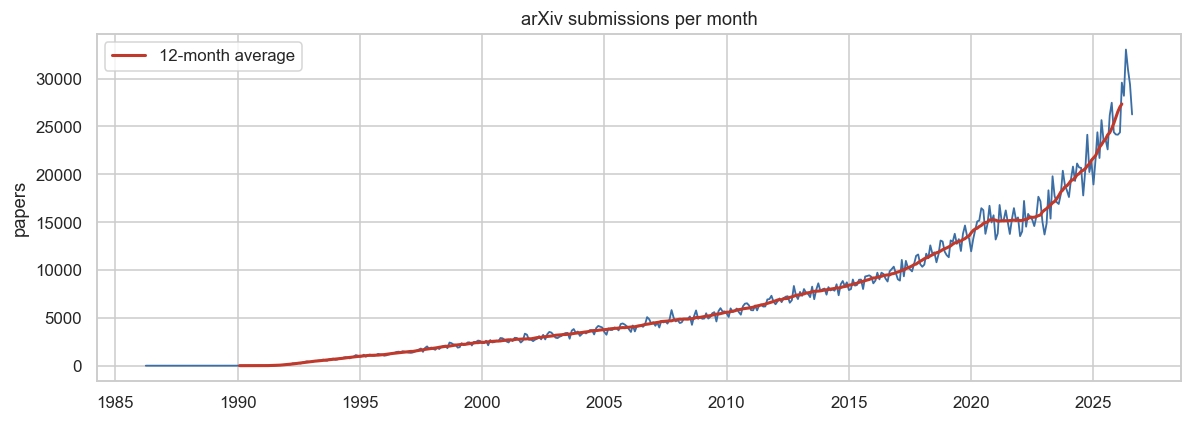

In [17]:
monthly = agg['monthly'].sort_values('month').copy()
monthly['date'] = pd.to_datetime(monthly['month'], format='%Y-%m', errors='coerce')
monthly = monthly.dropna(subset=['date'])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly['date'], monthly['papers'], lw=1.2, color='#3b6ea5')
ax.plot(monthly['date'], monthly['papers'].rolling(12, center=True).mean(),
        lw=2, color='#c0392b', label='12-month average')
ax.set_title('arXiv submissions per month'); ax.set_ylabel('papers'); ax.set_xlabel('')
ax.legend(); plt.tight_layout(); plt.show()

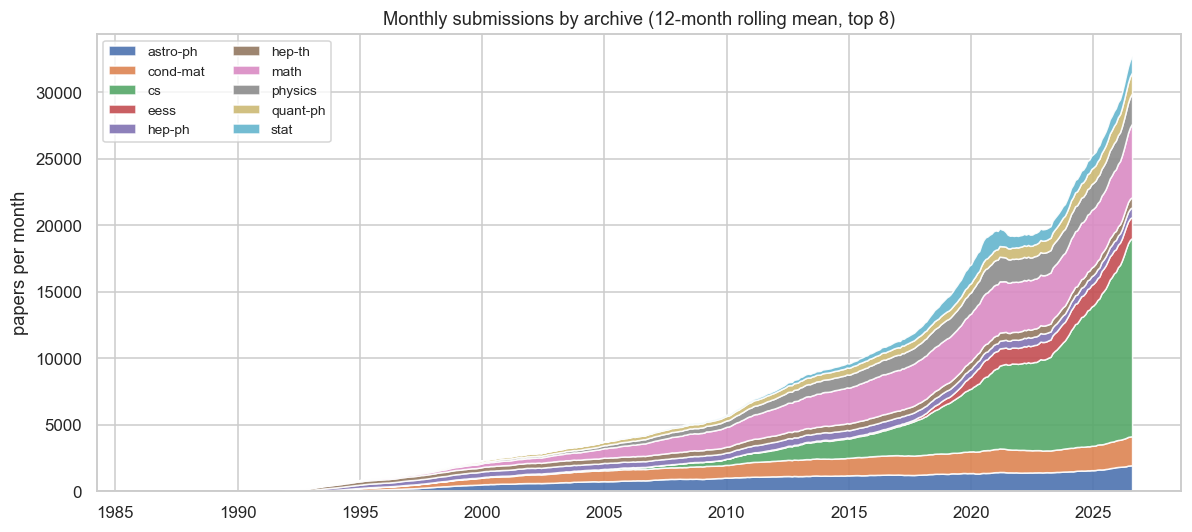

In [18]:
# Which archives drove that growth.
am = agg['archive_month'].copy()
am['date'] = pd.to_datetime(am['month'], format='%Y-%m', errors='coerce')
am = am.dropna(subset=['date'])
top_archives = (am.groupby('archive')['papers'].sum().nlargest(10).index.tolist())

wide = (am[am['archive'].isin(top_archives)]
        .pivot_table(index='date', columns='archive', values='papers', aggfunc='sum')
        .fillna(0).sort_index()
        .rolling(12, min_periods=1).mean())

fig, ax = plt.subplots(figsize=(11, 5))
ax.stackplot(wide.index, *[wide[c] for c in wide.columns], labels=list(wide.columns), alpha=0.9)
ax.set_title('Monthly submissions by archive (12-month rolling mean, top 8)')
ax.set_ylabel('papers per month'); ax.set_xlabel('')
ax.legend(loc='upper left', ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

## Category X Year

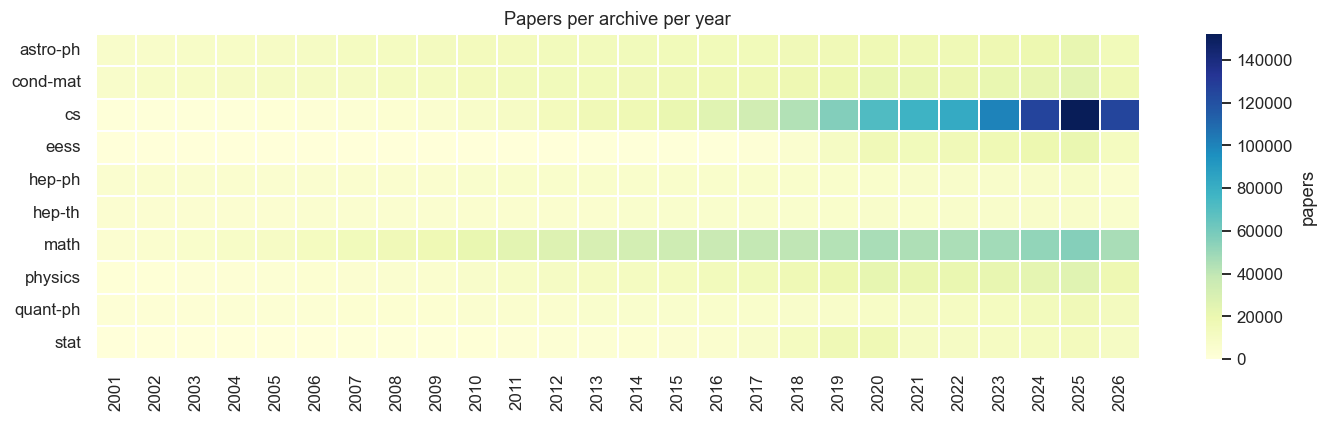

In [19]:
ay = agg['archive_year'].copy()
ay['year'] = pd.to_numeric(ay['year'], errors='coerce')
ay = ay.dropna(subset=['year'])
ay['year'] = ay['year'].astype(int)

heat = (ay[ay['archive'].isin(top_archives)]
        .pivot_table(index='archive', columns='year', values='papers', aggfunc='sum')
        .fillna(0))
heat = heat.loc[:, heat.columns >= heat.columns.max() - 25]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heat, cmap='YlGnBu', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'papers'})
ax.set_title('Papers per archive per year'); ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.show()

## Cross-listing

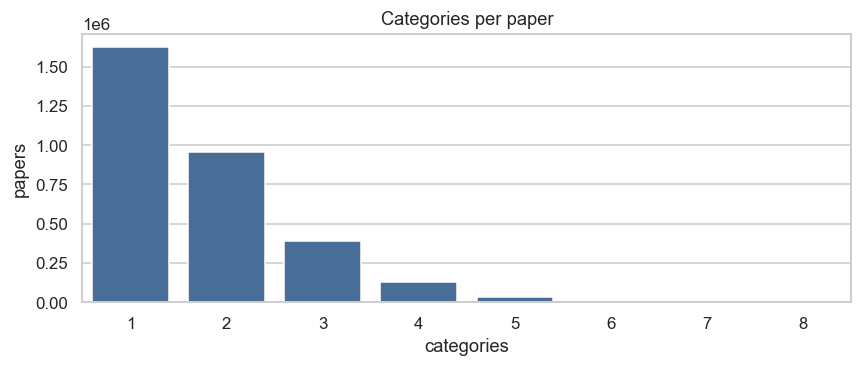

mean categories per paper: 1.74


,n_categories,papers,share_%
0,1,1627601,51.7
1,2,957885,30.4
2,3,389752,12.4
3,4,126626,4.0
4,5,37171,1.2
5,6,8359,0.3
6,7,1224,0.0
7,8,209,0.0
8,9,38,0.0
9,10,14,0.0


In [20]:
nc = agg['n_categories'].sort_values('n_categories')
nc['share_%'] = (nc['papers'] / TOTAL * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(data=nc[nc['n_categories'] <= 8], x='n_categories', y='papers', color='#3b6ea5', ax=ax)
ax.set_title('Categories per paper'); ax.set_xlabel('categories'); ax.set_ylabel('papers')
plt.tight_layout(); plt.show()

weighted = (nc['n_categories'] * nc['papers']).sum() / max(nc['papers'].sum(), 1)
print(f'mean categories per paper: {weighted:.2f}')
display(nc.reset_index(drop=True))

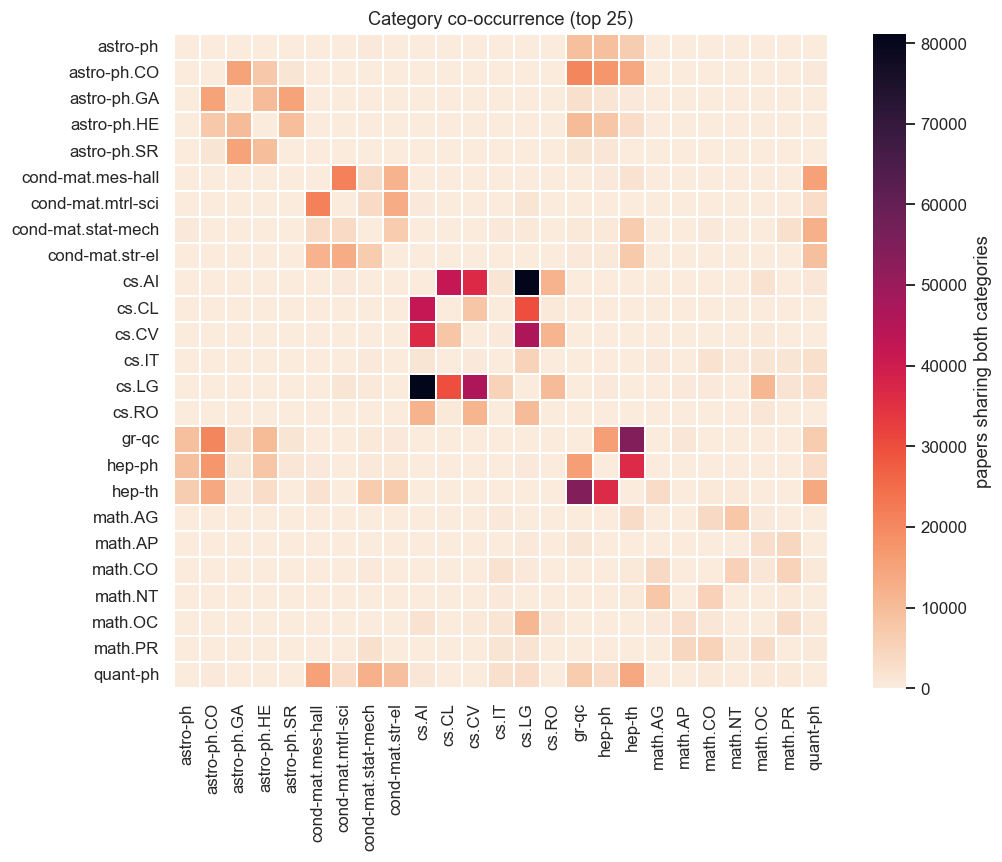

Strongest pairings:


,category_a,category_b,papers
0,cs.AI,cs.LG,81162
1,gr-qc,hep-th,54258
2,cs.CV,cs.LG,46383
3,cs.AI,cs.CL,42126
4,cs.AI,cs.CV,36753
5,hep-ph,hep-th,36279
6,cs.CL,cs.LG,29961
7,cond-mat.mes-hall,cond-mat.mtrl-sci,21321
8,astro-ph.CO,gr-qc,20597
9,astro-ph.CO,hep-ph,17552


In [21]:
# Co-occurrence among the most common categories.
TOP_CO = 25
keep = set(primary.head(TOP_CO)['category'])
co = agg['co_occurrence']
co = co[co['category_a'].isin(keep) & co['category_b'].isin(keep)]

if len(co):
    labels = sorted(keep)
    matrix = pd.DataFrame(0, index=labels, columns=labels)
    for a, b, n in co.itertuples(index=False):
        matrix.loc[a, b] = matrix.loc[b, a] = n
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(matrix, cmap='rocket_r', linewidths=0.3, square=True, ax=ax,
                cbar_kws={'label': 'papers sharing both categories'})
    ax.set_title(f'Category co-occurrence (top {TOP_CO})')
    plt.tight_layout(); plt.show()

    pairs = co.sort_values('papers', ascending=False).head(15).reset_index(drop=True)
    print('Strongest pairings:'); display(pairs)
else:
    print('no co-occurrence data in this snapshot')

## Check versions

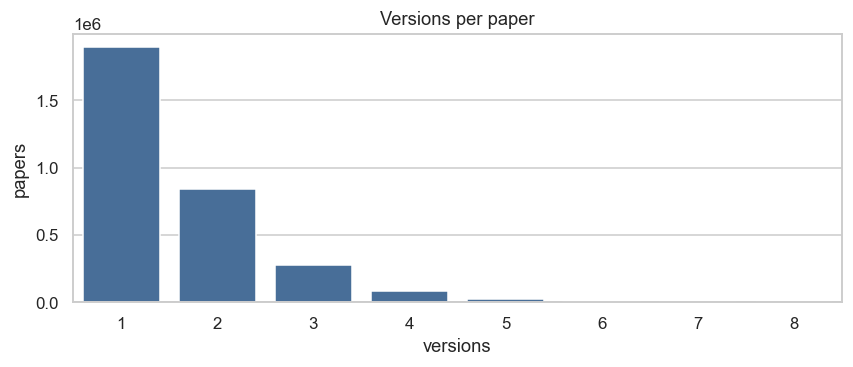

1,898,714 papers (60.3%) were never revised past v1


,n_versions,papers,share_%
0,1,1898714,60.3
1,2,842697,26.8
2,3,276532,8.8
3,4,84391,2.7
4,5,27579,0.9
...,...,...,...
67,99,1,0.0
68,103,2,0.0
69,152,1,0.0
70,166,1,0.0


In [22]:
nv = agg['n_versions'].sort_values('n_versions')
nv['share_%'] = (nv['papers'] / TOTAL * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(data=nv[nv['n_versions'] <= 8], x='n_versions', y='papers', color='#3b6ea5', ax=ax)
ax.set_title('Versions per paper'); ax.set_xlabel('versions'); ax.set_ylabel('papers')
plt.tight_layout(); plt.show()

single = int(nv.loc[nv['n_versions'] == 1, 'papers'].sum())
print(f'{single:,} papers ({single / TOTAL * 100:.1f}%) were never revised past v1')
display(nv.reset_index(drop=True))

## Title and abstract lengths

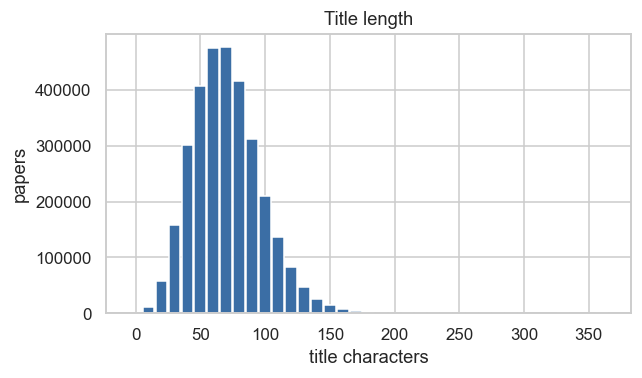

title_len      mean ≈ 71 characters


In [23]:
fig, ax = plt.subplots(figsize=(6, 3.6))
d = agg['title_len'].sort_values('chars')
d = d[d['chars'] <= d['chars'].quantile(0.999)]
ax.bar(d['chars'], d['papers'], width=(d['chars'].diff().median() or 1) * 0.9,
       color='#3b6ea5')
ax.set_xlabel('title characters'); ax.set_ylabel('papers')
ax.set_title('Title length')
plt.tight_layout(); plt.show()

d = agg['title_len']
weighted_mean = (d['chars'] * d['papers']).sum() / max(d['papers'].sum(), 1)
print(f'title_len      mean ≈ {weighted_mean:,.0f} characters')

## Planning a crawl

In [24]:
CONFIG['PLAN_CATEGORIES'] = []   # [] means the whole corpus
CONFIG['PLAN_FROM'] = None                  # None means no lower bound

# Measured on the smoke-test sample; refine with `python -m src.scripts.compare_size`.
CONFIG['MD_BYTES_PER_PAPER'] = 98_900
CONFIG['PDF_BYTES_PER_PAPER'] = 2_000_000
RPS = cfg.crawl.rate_per_sec

if CONFIG['PLAN_CATEGORIES']:
    scoped = int(allcats[allcats['category'].isin(CONFIG['PLAN_CATEGORIES'])]['papers'].sum())
    note = f"cross-listed to any of {CONFIG['PLAN_CATEGORIES']} (double-counts multi-category papers)"
else:
    scoped, note = TOTAL, 'the whole corpus'

if CONFIG['PLAN_FROM']:
    recent = monthly[monthly['month'] >= CONFIG['PLAN_FROM']]['papers'].sum()
    fraction = recent / max(monthly['papers'].sum(), 1)
    scoped = int(scoped * fraction)
    note += f', from {CONFIG['PLAN_FROM']} ({fraction:.0%} of all submissions)'

hours = scoped / RPS / 3600
print(f'scope            {note}')
print(f'papers           ~{scoped:,}')
print(f'download time    ~{hours:,.1f} h  ({hours / 24:,.1f} days) at {RPS} req/s')
print(f'                 ~{hours / 4:,.1f} h at 4 req/s, arXiv\'s stated ceiling')
print(f'Markdown output  ~{scoped * CONFIG['MD_BYTES_PER_PAPER'] / 1e9:,.1f} GB')
print(f'PDF transferred  ~{scoped * CONFIG['PDF_BYTES_PER_PAPER'] / 1e12:,.2f} TB (downloaded, then discarded)')
print()
print('Run it with:')
cat_flag = f" --categories {','.join(CONFIG['PLAN_CATEGORIES'])}" if CONFIG['PLAN_CATEGORIES'] else ''
from_flag = f' --from {CONFIG['PLAN_FROM']}' if CONFIG['PLAN_FROM'] else ''
print(f'  python -m src.main prepare{cat_flag}{from_flag}')
print('  python -m src.main run')

scope            the whole corpus
papers           ~3,148,882
download time    ~874.7 h  (36.4 days) at 1.0 req/s
                 ~218.7 h at 4 req/s, arXiv's stated ceiling
Markdown output  ~311.4 GB
PDF transferred  ~6.30 TB (downloaded, then discarded)

Run it with:
  python -m src.main prepare
  python -m src.main run
